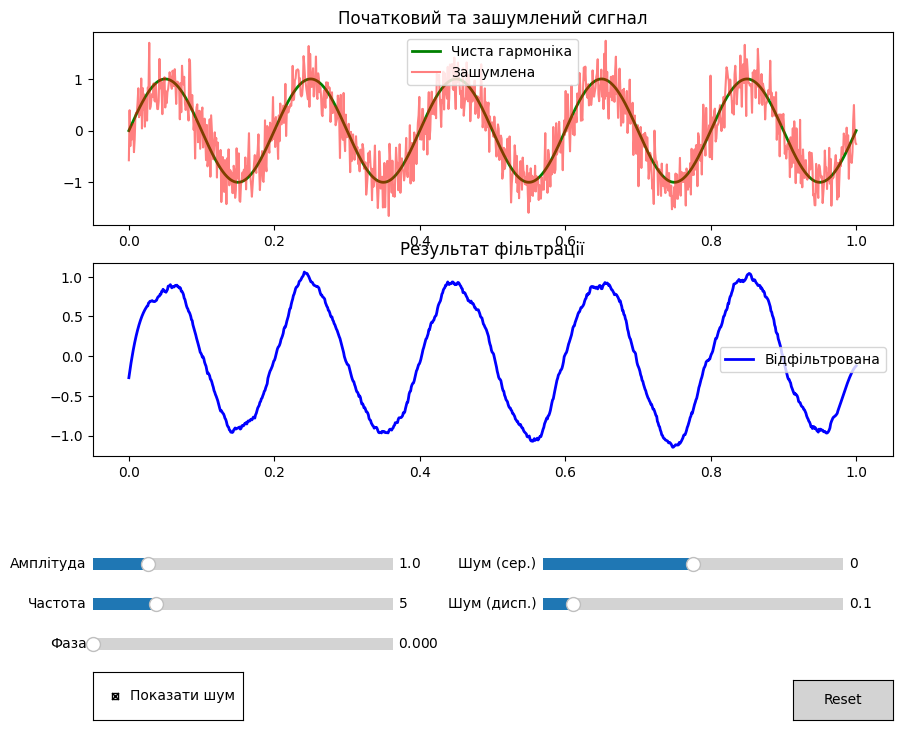

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import savgol_filter

# 1. Функція генерації гармоніки з шумом
def harmonic_with_noise(t, amplitude, frequency, phase, noise_mean, noise_covariance, show_noise):
    harmonic = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    if show_noise:
        # Використовуємо фіксований seed для шуму, щоб він не мінявся при зміні гармоніки
        noise = np.random.normal(noise_mean, np.sqrt(noise_covariance), len(t))
        return harmonic, harmonic + noise
    else:
        return harmonic, harmonic

# Параметри часу
t = np.linspace(0, 1, 1000)

# Початкові значення
init_amp = 1.0
init_freq = 5.0
init_phase = 0.0
init_noise_mean = 0.0
init_noise_cov = 0.1

# Створення вікна
fig, (ax_orig, ax_filt) = plt.subplots(2, 1, figsize=(10, 8))
plt.subplots_adjust(left=0.1, bottom=0.35)

# Генерація початкових даних
h_pure, h_noisy = harmonic_with_noise(t, init_amp, init_freq, init_phase, init_noise_mean, init_noise_cov, True)
filtered = savgol_filter(h_noisy, 51, 3)

line_pure, = ax_orig.plot(t, h_pure, label='Чиста гармоніка', color='green', lw=2)
line_noisy, = ax_orig.plot(t, h_noisy, label='Зашумлена', color='red', alpha=0.5)
line_filt, = ax_filt.plot(t, filtered, label='Відфільтрована', color='blue', lw=2)

ax_orig.legend()
ax_filt.legend()
ax_orig.set_title("Початковий та зашумлений сигнал")
ax_filt.set_title("Результат фільтрації")

# Налаштування слайдерів (позиція: [left, bottom, width, height])
ax_amp = plt.axes([0.1, 0.20, 0.3, 0.03])
ax_freq = plt.axes([0.1, 0.15, 0.3, 0.03])
ax_phase = plt.axes([0.1, 0.10, 0.3, 0.03])

ax_n_mean = plt.axes([0.55, 0.20, 0.3, 0.03])
ax_n_cov = plt.axes([0.55, 0.15, 0.3, 0.03])

s_amp = Slider(ax_amp, 'Амплітуда', 0.1, 5.0, valinit=init_amp)
s_freq = Slider(ax_freq, 'Частота', 1.0, 20.0, valinit=init_freq)
s_phase = Slider(ax_phase, 'Фаза', 0.0, 2*np.pi, valinit=init_phase)

s_n_mean = Slider(ax_n_mean, 'Шум (сер.)', -1.0, 1.0, valinit=init_noise_mean)
s_n_cov = Slider(ax_n_cov, 'Шум (дисп.)', 0.0, 1.0, valinit=init_noise_cov)

# Чекбокс та кнопка
ax_check = plt.axes([0.1, 0.02, 0.15, 0.06])
check = CheckButtons(ax_check, ['Показати шум'], [True])

ax_reset = plt.axes([0.8, 0.02, 0.1, 0.05])
button = Button(ax_reset, 'Reset', color='lightgray')

# Змінна для зберігання шуму (щоб не генерувати наново)
current_noise = np.random.normal(init_noise_mean, np.sqrt(init_noise_cov), len(t))

def update(val):
    global current_noise
    amp = s_amp.val
    freq = s_freq.val
    phase = s_phase.val
    n_mean = s_n_mean.val
    n_cov = s_n_cov.val
    show_n = check.get_status()[0]
    
    # Якщо змінили параметри шуму — генеруємо новий шум
    if val in [s_n_mean.val, s_n_cov.val]:
        current_noise = np.random.normal(n_mean, np.sqrt(n_cov), len(t))
    
    harmonic = amp * np.sin(2 * np.pi * freq * t + phase)
    line_pure.set_ydata(harmonic)
    
    if show_n:
        noisy_signal = harmonic + current_noise
        line_noisy.set_ydata(noisy_signal)
        line_noisy.set_visible(True)
    else:
        noisy_signal = harmonic
        line_noisy.set_visible(False)
        
    # Оновлюємо фільтр
    line_filt.set_ydata(savgol_filter(noisy_signal, 51, 3))
    
    fig.canvas.draw_idle()

s_amp.on_changed(update)
s_freq.on_changed(update)
s_phase.on_changed(update)
s_n_mean.on_changed(update)
s_n_cov.on_changed(update)
check.on_clicked(update)

def reset(event):
    s_amp.reset()
    s_freq.reset()
    s_phase.reset()
    s_n_mean.reset()
    s_n_cov.reset()
button.on_clicked(reset)

plt.show()